# 2.2. Practica. Análisis, implementación y prueba de máquinas de aprendizaje supervisado (Parte I)

## Introducción de la actividad

Dada una base de datos 𝐷={𝑡1,𝑡2,…,𝑡𝑛} de tuplas o registros (individuos) y un conjunto de clases 𝐶={𝐶1,𝐶2,…,𝐶𝑚}, el problema de la clasificación es encontrar una función 𝑓:𝐷→𝐶 tal que cada 𝑡𝑖 es asignada una clase 𝐶𝑗. 𝑓:𝐷→𝐶 podría ser KNN, un Árbol de Decisión, un Modelo Bayesiano, etc.

El análisis, implementación y prueba de las máquinas de aprendizaje supervisado (Parte I: KNN, Árbol de Decisión y Modelo Bayesiano) permitirá comprender el funcionamiento de cada una de las máquinas de forma clara y precisa.

## Propósito de la actividad

Comprender el funcionamiento de las máquinas de aprendizaje supervisado (Parte I: KNN, Árbol de Decisión y Modelo Bayesiano).

## Instrucciones

Analicé, implemente y evalué máquinas de aprendizaje supervisado (Parte I: KNN, Árbol de Decisión y Modelo Bayesiano), la implementación de las máquinas será en el lenguaje de su preferencia. Deberá contener:

- Portada

- Análisis de las máquinas de aprendizaje supervisado (explique el funcionamiento de los modelos predictivos utilizando la curva rock (utilice al menos dos modelos)).

- Implementación de las máquinas de aprendizaje supervisado (implemente al menos dos algoritmos utilizando la curva rock).

- Evaluación de las máquinas de aprendizaje supervisado (análisis comparativo de los modelos predictivos utilizando la gráfica de la curva rock como métrica de comparación (utilice al menos dos modelos)).

- Conclusiones.

## Dependencias

| Librería | Propósito en esta práctica |
|---|---|
| `numpy` | Operaciones vectoriales sobre los datos, distancias y estadísticos de las implementaciones manuales |
| `pandas` | Inspección tabular del dataset y construcción de la tabla comparativa de métricas |
| `matplotlib` | Visualización de la proyección PCA, la selección de `k` y las curvas ROC |
| `scikit-learn` | Dataset (`load_breast_cancer`), utilidades (`train_test_split`, `StandardScaler`, `PCA`, métricas) e implementaciones de referencia (`KNeighborsClassifier`, `GaussianNB`) para validar las versiones manuales |

In [1]:
import sys
import subprocess
import importlib

required = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "scikit-learn": "sklearn",
}

for package, import_name in required.items():
    if importlib.util.find_spec(import_name) is None:
        print(f"Instalando {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

import numpy as np
import pandas as pd
import matplotlib
import sklearn

print(f"Python       {sys.version}")
print(f"numpy        {np.__version__}")
print(f"pandas       {pd.__version__}")
print(f"matplotlib   {matplotlib.__version__}")
print(f"scikit-learn {sklearn.__version__}")

Python       3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
numpy        2.3.3
pandas       2.3.3
matplotlib   3.10.7
scikit-learn 1.7.2


## Dataset: Breast Cancer Wisconsin (Diagnostic)

Se utiliza el dataset **Breast Cancer Wisconsin (Diagnostic)** (Wolberg, Street & Mangasarian), originalmente publicado en el *UCI Machine Learning Repository*. No es necesario descargarlo manualmente: **scikit-learn lo incluye empaquetado** dentro de la propia librería y se carga de forma local, sin conexión a internet, con:

```python
from sklearn.datasets import load_breast_cancer
```

**Características (30, numéricas):** medidas geométricas y de textura calculadas a partir de imágenes digitalizadas de núcleos celulares obtenidos por punción con aguja fina (radio, textura, perímetro, área, suavidad, etc., junto con su error estándar y su valor "peor caso").

**Clase objetivo (`target`, binaria):**
- **0** — Maligno
- **1** — Benigno

Con 569 muestras en total, el dataset tiene tamaño suficiente para dividirlo en entrenamiento/prueba y obtener una curva ROC informativa.

Como las 30 características tienen escalas muy distintas (por ejemplo, `area` frente a `smoothness`), se estandarizan con `StandardScaler` (media 0, desviación 1) ajustado únicamente sobre el conjunto de entrenamiento. Esto es indispensable para KNN, que basa sus predicciones en distancias euclidianas: sin escalar, las características de mayor magnitud dominarían el cálculo de la distancia.

Como no es posible graficar directamente 30 dimensiones, se proyectan los datos escalados a 2 componentes principales (`PCA`) únicamente con fines de visualización exploratoria — los modelos se entrenan sobre las 30 características originales (escaladas), no sobre la proyección.

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

dataset = load_breast_cancer()
X, y = dataset.data, dataset.target

df = pd.DataFrame(X, columns=dataset.feature_names)
df["target"] = y

print(f"Muestras: {X.shape[0]}, características: {X.shape[1]}")
print(f"Clases: {dict(zip(*np.unique(y, return_counts=True)))} (0=maligno, 1=benigno)")
df.head()

Muestras: 569, características: 30
Clases: {np.int64(0): np.int64(212), np.int64(1): np.int64(357)} (0=maligno, 1=benigno)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=26
)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Entrenamiento: {X_train_s.shape[0]} muestras")
print(f"Prueba:        {X_test_s.shape[0]} muestras")

Entrenamiento: 398 muestras
Prueba:        171 muestras


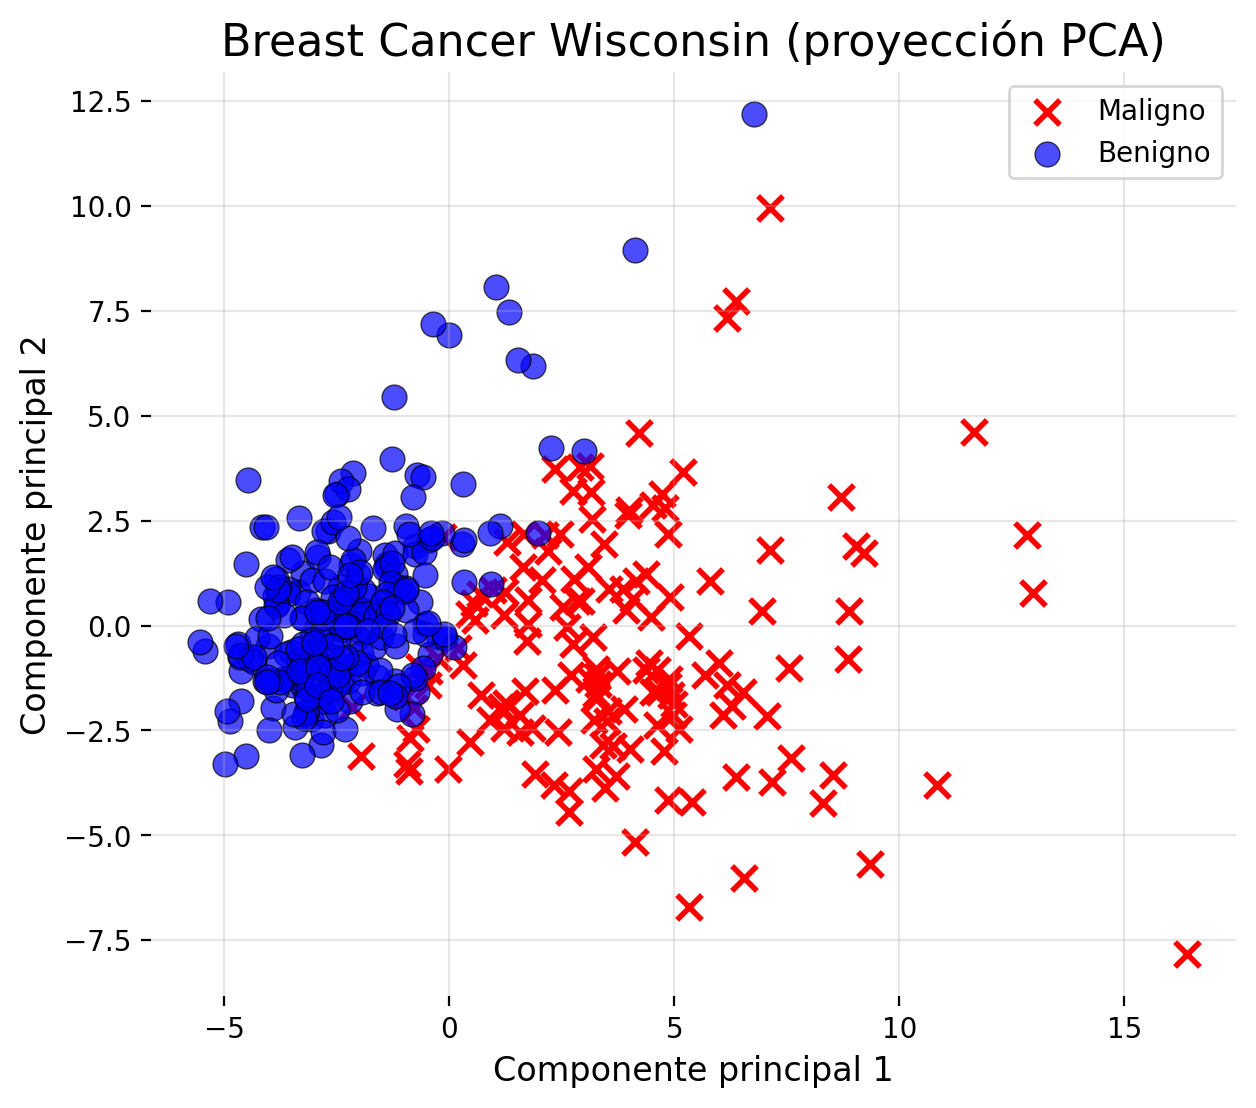

In [4]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_pca = PCA(n_components=2, random_state=26).fit_transform(X_train_s)

plt.figure(figsize=(7, 6), dpi=200)
plt.title("Breast Cancer Wisconsin (proyección PCA)", fontsize=16)

plt.scatter(X_pca[y_train == 0, 0], X_pca[y_train == 0, 1],
            marker="x", s=80, color="red", linewidths=2, label="Maligno")
plt.scatter(X_pca[y_train == 1, 0], X_pca[y_train == 1, 1],
            marker="o", s=80, color="blue", linewidths=0.5,
            edgecolors="black", alpha=0.7, label="Benigno")

plt.xlabel("Componente principal 1", fontsize=12)
plt.ylabel("Componente principal 2", fontsize=12)
plt.legend()
plt.box(False)
plt.grid(alpha=0.3)
plt.show()

# Análisis de las máquinas de aprendizaje supervisado

## 1. K-Nearest Neighbors (KNN)

KNN es un algoritmo de aprendizaje **perezoso** (*lazy learning*): no ajusta parámetros durante un "entrenamiento", sino que memoriza todas las instancias de entrenamiento y difiere el cómputo hasta el momento de predecir.

**Funcionamiento:**
1. Dado un punto nuevo $x$, se calcula su distancia (típicamente euclidiana) a **todos** los puntos de entrenamiento:
$$d(x, x_i) = \sqrt{\sum_{j=1}^{n} (x_j - x_{i,j})^2}$$
2. Se seleccionan los $k$ puntos de entrenamiento más cercanos a $x$.
3. Se predice la clase por **voto mayoritario** entre esos $k$ vecinos. La probabilidad de pertenecer a la clase positiva se puede estimar como la fracción de vecinos que pertenecen a esa clase:
$$P(y=1 \mid x) \approx \frac{1}{k}\sum_{i \in N_k(x)} \mathbb{1}[y_i = 1]$$

**El parámetro $k$:**
- $k$ pequeño → frontera de decisión muy flexible, sensible al ruido (riesgo de sobreajuste).
- $k$ grande → frontera más suave, pero puede ignorar patrones locales (riesgo de subajuste).
- Al ser un modelo basado en distancias, **requiere que las características estén en escalas comparables** (de ahí el `StandardScaler` aplicado al dataset).

**Pseudocódigo:**
```
Para cada punto de prueba x:
    Calcular distancia(x, x_i) para todo x_i en el conjunto de entrenamiento
    Ordenar los puntos de entrenamiento por distancia ascendente
    Tomar los k más cercanos (vecinos)
    Predicción = clase mayoritaria entre los vecinos
    Probabilidad = proporción de vecinos de la clase positiva
```

## 2. Naive Bayes Gaussiano

Naive Bayes es un clasificador **probabilístico** basado en el teorema de Bayes. La idea central es invertir la pregunta: en vez de preguntar directamente "¿cuál es la clase de $x$?", se pregunta "¿qué tan probable es haber observado $x$ si la clase fuera $y$?", y se usa esa respuesta para deducir la clase más probable.

### 2.1 Punto de partida: el teorema de Bayes

Para una sola observación $x$ (por ahora tratada como un solo número, no un vector) y una clase $y$, el teorema de Bayes establece:

$$P(y \mid x) = \frac{P(x \mid y)\, P(y)}{P(x)}$$

Cada término tiene un nombre y un rol concreto:

| Término | Nombre | Significado |
|---|---|---|
| $P(y \mid x)$ | **Posterior** | Lo que queremos conocer: la probabilidad de la clase $y$ *después* de observar $x$ |
| $P(x \mid y)$ | **Verosimilitud** (*likelihood*) | Qué tan típico es el valor $x$ dentro de la clase $y$ |
| $P(y)$ | **Prior** | Probabilidad de la clase $y$ *antes* de ver ningún dato (su frecuencia relativa) |
| $P(x)$ | **Evidencia** | Probabilidad total de observar $x$, sumando sobre todas las clases: $P(x) = \sum_{y'} P(x \mid y') P(y')$ |

Para **clasificar** no es necesario calcular $P(x)$: dado un mismo punto $x$, el denominador es idéntico para todas las clases, así que solo actúa como una constante de normalización. Basta con encontrar qué clase maximiza el numerador:

$$P(y \mid x) \propto P(x \mid y)\, P(y)$$

### 2.2 El supuesto "ingenuo": independencia condicional

Cuando $x$ tiene varias características $x_1, \dots, x_n$ (en este dataset, $n=30$), calcular $P(x_1,\dots,x_n \mid y)$ directamente requeriría modelar todas las interacciones entre características, lo cual es intratable con pocos datos. Naive Bayes evita esto asumiendo que, **una vez fijada la clase**, las características son independientes entre sí:

$$P(x_1, \dots, x_n \mid y) = \prod_{j=1}^{n} P(x_j \mid y)$$

Esto significa, por ejemplo, que se asume que conocer el `mean radius` de un tumor no aporta información adicional sobre su `mean area` *si ya se sabe que la clase es "maligno"*. Combinando esto con el teorema de Bayes:

$$P(y \mid x_1, \dots, x_n) \propto P(y) \prod_{j=1}^{n} P(x_j \mid y)$$

Es "ingenuo" precisamente porque en datasets reales las características casi siempre están correlacionadas (como se discute más adelante en la sección de Evaluación), pero aun así el modelo suele funcionar razonablemente bien en la práctica.

### 2.3 La verosimilitud gaussiana: modelando $P(x_j \mid y)$

Falta definir cómo calcular $P(x_j \mid y)$ para una característica continua. La variante **Gaussiana** asume que, dentro de cada clase, cada característica $x_j$ se distribuye como una campana de Gauss (distribución normal):

$$P(x_j \mid y) = \frac{1}{\sqrt{2\pi\sigma_{y,j}^2}} \exp\left(-\frac{(x_j - \mu_{y,j})^2}{2\sigma_{y,j}^2}\right)$$

Desglosando la fórmula:
- $\mu_{y,j}$ es la **media** de la característica $j$ entre los ejemplos de entrenamiento de la clase $y$ — el "valor típico" de esa característica en esa clase.
- $\sigma_{y,j}^2$ es la **varianza** de esa característica dentro de esa clase — qué tan dispersos están los valores alrededor de la media.
- El término $(x_j - \mu_{y,j})^2$ mide qué tan lejos está el valor observado $x_j$ de ese promedio; entre más lejos, más pequeño el resultado de la exponencial (menos probable).
- Dividir entre $2\sigma_{y,j}^2$ hace que esa distancia "importe menos" cuando la clase tiene naturalmente mucha dispersión (varianza grande), y "importe más" cuando la clase es muy homogénea (varianza pequeña).
- El factor $\frac{1}{\sqrt{2\pi\sigma_{y,j}^2}}$ al frente es solo una constante de normalización que asegura que el área bajo la curva de densidad sea igual a 1; no cambia *dónde* está el máximo, solo escala la curva completa.

En otras palabras: la característica $x_j$ es "probable" bajo la clase $y$ si está cerca de la media histórica de esa clase, y esa cercanía se mide en unidades de la propia dispersión de la clase.

### 2.4 Entrenamiento (fit)

Entrenar Naive Bayes Gaussiano no implica optimizar nada iterativamente: los tres parámetros que necesita se calculan **directamente** a partir de los datos de entrenamiento (son los estimadores de máxima verosimilitud de una normal):

$$\mu_{y,j} = \frac{1}{N_y}\sum_{i:\, y_i=y} x_{i,j} \qquad \sigma_{y,j}^2 = \frac{1}{N_y}\sum_{i:\, y_i=y} (x_{i,j} - \mu_{y,j})^2 \qquad P(y) = \frac{N_y}{N}$$

donde $N_y$ es el número de ejemplos de entrenamiento de la clase $y$, y $N$ el total. Es decir: **una media y una varianza por cada combinación (clase, característica)**, más un prior por clase.

### 2.5 Predicción

Para un punto nuevo $x = (x_1, \dots, x_n)$, se evalúa el numerador del teorema de Bayes para cada clase posible y se normaliza entre todas las clases para obtener probabilidades que sumen 1:

$$P(y \mid x) = \frac{P(y)\displaystyle\prod_{j=1}^n P(x_j \mid y)}{\displaystyle\sum_{y'} P(y')\prod_{j=1}^n P(x_j \mid y')}$$

El numerador de cada clase es un producto de 30 densidades gaussianas (una por característica) multiplicado por el prior; el denominador es simplemente la suma de esos numeradores sobre las dos clases posibles (maligno y benigno), y actúa como constante de normalización para que el resultado sea una probabilidad válida.

**Nota de implementación:** multiplicar 30 números entre 0 y 1 puede producir un valor extremadamente pequeño y perderse por *underflow* numérico. Por eso, en el código se trabaja con logaritmos: $\log\big(\prod_j P(x_j\mid y)\big) = \sum_j \log P(x_j \mid y)$, se suman los logaritmos en vez de multiplicar las probabilidades, y solo al final se aplica $\exp$ para recuperar la escala de probabilidad — sin cambiar el resultado matemático, solo su estabilidad numérica.

A diferencia de KNN, Naive Bayes **no requiere memorizar los datos de entrenamiento** (solo guarda medias, varianzas y priors) ni es sensible a la escala de las variables (solo a qué tan bien se ajuste el supuesto de normalidad), pero su suposición de independencia entre características rara vez se cumple exactamente en la práctica.

## 3. Curva ROC (Receiver Operating Characteristic)

Tanto KNN como Naive Bayes no solo predicen una clase, sino que producen una **probabilidad** o *score* de pertenecer a la clase positiva. Para clasificar, ese score se compara contra un umbral (por defecto 0.5), pero **variar el umbral cambia el balance entre aciertos y falsos positivos**.

La curva ROC gráfica, para todos los umbrales posibles:

$$\text{TPR (sensibilidad)} = \frac{TP}{TP + FN} \qquad \text{FPR} = \frac{FP}{FP + TN}$$

- El eje X es la Tasa de Falsos Positivos (FPR) y el eje Y la Tasa de Verdaderos Positivos (TPR).
- La diagonal ($y=x$) representa un clasificador aleatorio (sin poder discriminativo).
- Cuanto más se acerque la curva a la esquina superior izquierda, mejor separa el modelo ambas clases.

El **AUC** (área bajo la curva) resume la curva en un solo número entre 0 y 1: la probabilidad de que el modelo asigne un score mayor a una muestra positiva elegida al azar que a una negativa. Es una métrica que **no depende de elegir un umbral específico**, lo que la hace ideal para comparar de forma justa dos modelos —como KNN y Naive Bayes— que producen probabilidades por mecanismos completamente distintos (votación por vecindad vs. densidad gaussiana).

# Implementación

## Implementación manual de KNN

Se implementa `knn_predict_proba`, que calcula la distancia euclidiana del punto de prueba a cada punto de entrenamiento, toma los `k` vecinos más cercanos y devuelve la proporción de vecinos de la clase positiva (1 = benigno) como probabilidad estimada.

Como prueba, se evalúa sobre el primer punto del conjunto de prueba y se compara contra su clase real.

In [5]:
def knn_predict_proba(X_train, y_train, x, k):
    distancias = np.sqrt(np.sum((X_train - x) ** 2, axis=1))
    vecinos = np.argsort(distancias)[:k]
    return y_train[vecinos].mean()


def knn_predict_proba_batch(X_train, y_train, X_query, k):
    return np.array([knn_predict_proba(X_train, y_train, x, k) for x in X_query])


x0 = X_test_s[0]
proba_manual = knn_predict_proba(X_train_s, y_train, x0, k=5)
print(f"P(benigno | x0) estimada por KNN manual (k=5): {proba_manual:.2f}")
print(f"Clase real de x0: {y_test[0]} ({'benigno' if y_test[0] == 1 else 'maligno'})")

P(benigno | x0) estimada por KNN manual (k=5): 0.00
Clase real de x0: 0 (maligno)


### Selección de `k`

Para elegir un valor de `k` razonable (en vez de fijarlo arbitrariamente), se evalúa la exactitud promedio con validación cruzada (5 *folds*) sobre el conjunto de entrenamiento para distintos valores impares de `k`, usando `KNeighborsClassifier` de scikit-learn como herramienta de búsqueda (no como el modelo final — el modelo final seguirá siendo la implementación manual).

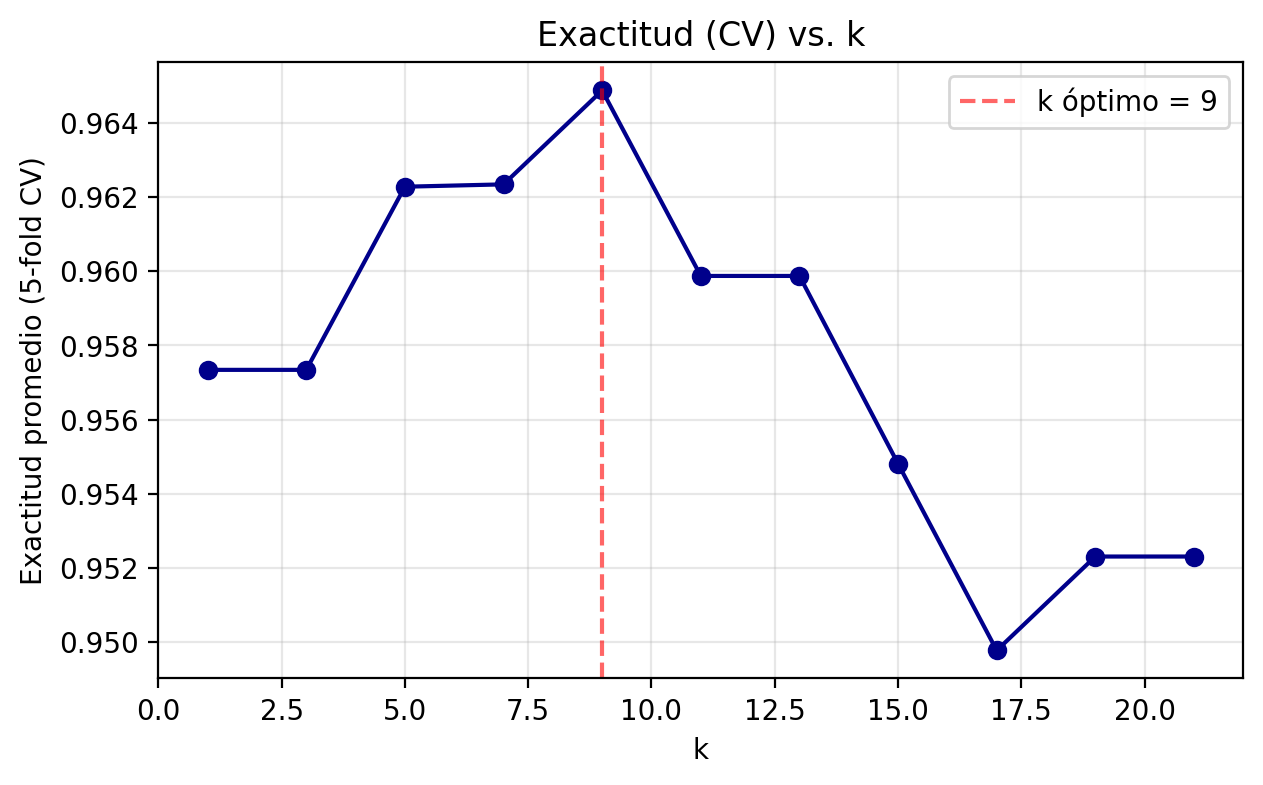

k óptimo elegido: 9 (exactitud CV = 0.9649)


In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

valores_k = list(range(1, 22, 2))
precision_cv = [
    cross_val_score(KNeighborsClassifier(n_neighbors=k), X_train_s, y_train, cv=5).mean()
    for k in valores_k
]

k_optimo = valores_k[int(np.argmax(precision_cv))]

plt.figure(figsize=(7, 4), dpi=200)
plt.plot(valores_k, precision_cv, marker="o", color="darkblue")
plt.axvline(k_optimo, color="red", linestyle="--", alpha=0.6, label=f"k óptimo = {k_optimo}")
plt.title("Exactitud (CV) vs. k")
plt.xlabel("k")
plt.ylabel("Exactitud promedio (5-fold CV)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"k óptimo elegido: {k_optimo} (exactitud CV = {max(precision_cv):.4f})")

## Implementación manual de Naive Bayes Gaussiano

Se implementa la clase `GaussianNaiveBayes`:
- `fit`: para cada clase, calcula la media, la varianza (con un pequeño término de suavizado para evitar divisiones por cero) y el prior.
- `predict_proba`: evalúa la densidad gaussiana de cada característica para cada clase, multiplica por el prior, y normaliza para obtener una probabilidad posterior.

**Pseudocódigo:**
```
Entrenamiento (fit):
    Para cada clase c:
        media[c]    = promedio de las características de los ejemplos de clase c
        varianza[c] = varianza de las características de los ejemplos de clase c
        prior[c]    = (número de ejemplos de clase c) / (total de ejemplos)

Predicción (predict_proba) para un punto x:
    Para cada clase c:
        verosimilitud[c] = producto_j Gaussiana(x_j; media[c,j], varianza[c,j])
        posterior_no_normalizado[c] = prior[c] * verosimilitud[c]
    P(y=c | x) = posterior_no_normalizado[c] / suma(posterior_no_normalizado)
```

Como prueba, se evalúa sobre el mismo punto usado para KNN.

In [7]:
class GaussianNaiveBayes:
    def fit(self, X, y):
        self.clases = np.unique(y)
        self.media = {}
        self.varianza = {}
        self.prior = {}
        eps = 1e-9  # evita varianzas de 0
        for c in self.clases:
            Xc = X[y == c]
            self.media[c] = Xc.mean(axis=0)
            self.varianza[c] = Xc.var(axis=0) + eps
            self.prior[c] = Xc.shape[0] / X.shape[0]
        return self

    def _log_verosimilitud(self, x, c):
        media, var = self.media[c], self.varianza[c]
        log_gaussiana = -0.5 * np.log(2 * np.pi * var) - ((x - media) ** 2) / (2 * var)
        return log_gaussiana.sum()  # log del producto = suma de logs

    def predict_proba(self, X):
        probas = []
        for x in X:
            log_posterior = np.array([
                np.log(self.prior[c]) + self._log_verosimilitud(x, c) for c in self.clases
            ])
            log_posterior -= log_posterior.max()  # estabilidad numérica
            posterior = np.exp(log_posterior)
            probas.append(posterior / posterior.sum())
        return np.array(probas)

    def predict(self, X):
        return self.clases[np.argmax(self.predict_proba(X), axis=1)]


nb_manual = GaussianNaiveBayes().fit(X_train_s, y_train)
proba_nb_manual = nb_manual.predict_proba(x0.reshape(1, -1))[0]
print(f"P(maligno, benigno | x0) estimada por Naive Bayes manual: {proba_nb_manual}")
print(f"Clase real de x0: {y_test[0]} ({'benigno' if y_test[0] == 1 else 'maligno'})")

P(maligno, benigno | x0) estimada por Naive Bayes manual: [1.0000000e+00 6.2087059e-54]
Clase real de x0: 0 (maligno)


## Validación contra scikit-learn

Para confirmar que las implementaciones manuales son correctas, se entrenan `KNeighborsClassifier(n_neighbors=k_optimo)` y `GaussianNB()` de scikit-learn con los mismos datos, y se comparan sus probabilidades predichas sobre el conjunto de prueba contra las de `knn_predict_proba_batch` y `GaussianNaiveBayes`. Si la diferencia máxima es cercana a 0, las implementaciones manuales quedan verificadas (igual que se validó el perceptrón manual contra `sklearn.linear_model.Perceptron` en la práctica anterior).

In [8]:
from sklearn.naive_bayes import GaussianNB

knn_sklearn = KNeighborsClassifier(n_neighbors=k_optimo).fit(X_train_s, y_train)
nb_sklearn = GaussianNB().fit(X_train_s, y_train)

proba_knn_manual = knn_predict_proba_batch(X_train_s, y_train, X_test_s, k=k_optimo)
proba_knn_sklearn = knn_sklearn.predict_proba(X_test_s)[:, 1]

proba_nb_manual_all = nb_manual.predict_proba(X_test_s)[:, 1]
proba_nb_sklearn = nb_sklearn.predict_proba(X_test_s)[:, 1]

print(f"KNN — diferencia máxima manual vs. sklearn: {np.max(np.abs(proba_knn_manual - proba_knn_sklearn)):.6f}")
print(f"NB  — diferencia máxima manual vs. sklearn: {np.max(np.abs(proba_nb_manual_all - proba_nb_sklearn)):.6f}")

KNN — diferencia máxima manual vs. sklearn: 0.000000
NB  — diferencia máxima manual vs. sklearn: 0.000000


## Curva ROC de ambos modelos

Usando las probabilidades de la clase positiva (benigno) predichas por cada modelo sobre el conjunto de prueba, se calcula la curva ROC (`roc_curve`) y el AUC (`roc_auc_score`) de scikit-learn — herramientas de evaluación, no los algoritmos en sí, que ya fueron implementados manualmente arriba — y se grafican ambas curvas junto con la diagonal de referencia.

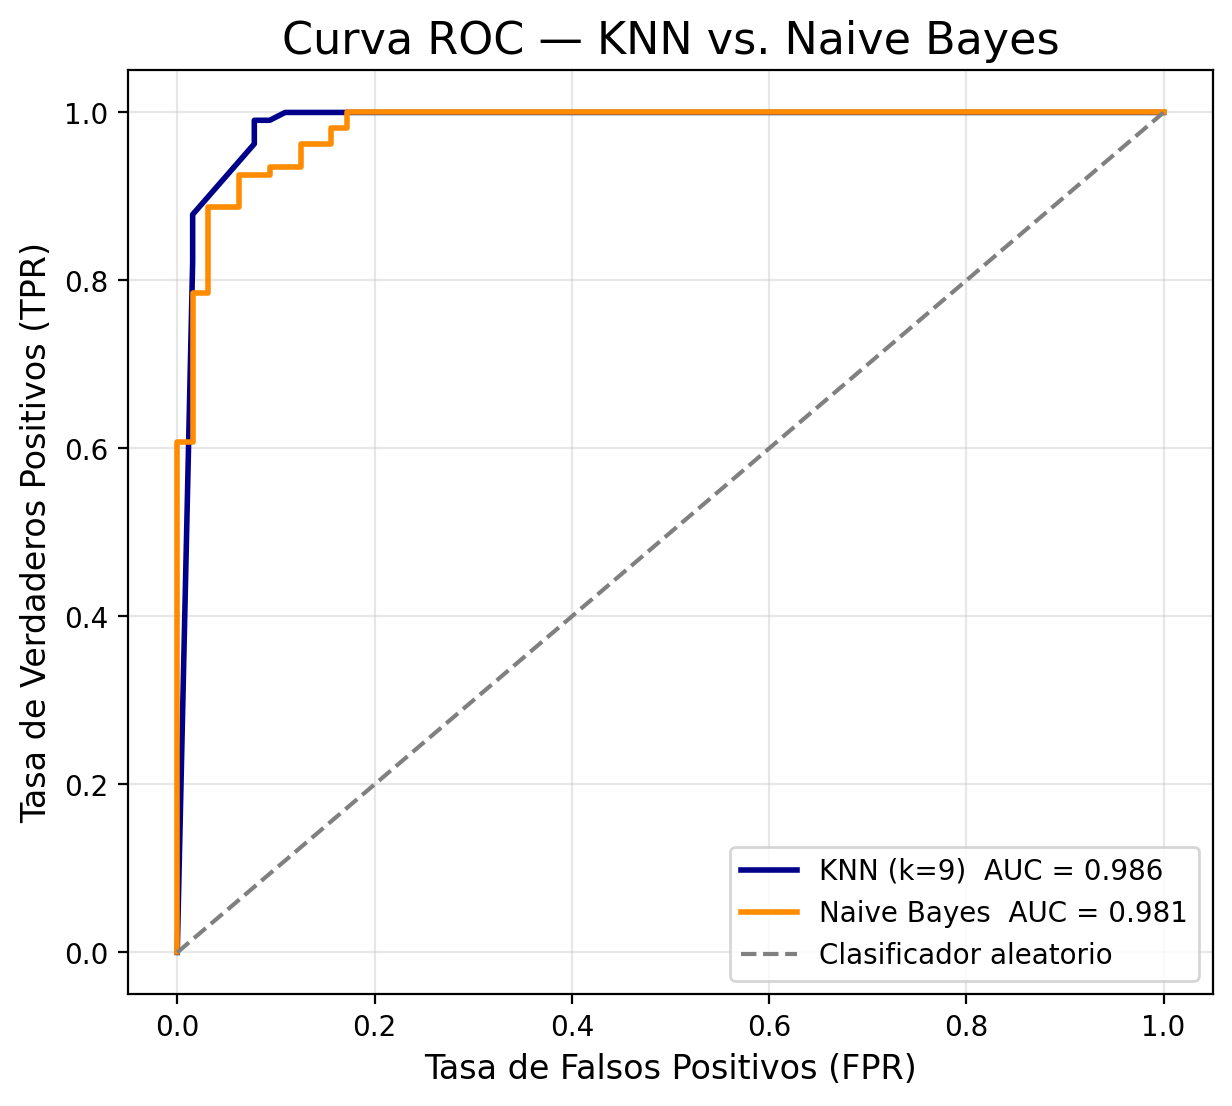

In [9]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_knn, tpr_knn, _ = roc_curve(y_test, proba_knn_manual)
auc_knn = roc_auc_score(y_test, proba_knn_manual)

fpr_nb, tpr_nb, _ = roc_curve(y_test, proba_nb_manual_all)
auc_nb = roc_auc_score(y_test, proba_nb_manual_all)

plt.figure(figsize=(7, 6), dpi=200)
plt.plot(fpr_knn, tpr_knn, color="darkblue", linewidth=2, label=f"KNN (k={k_optimo})  AUC = {auc_knn:.3f}")
plt.plot(fpr_nb, tpr_nb, color="darkorange", linewidth=2, label=f"Naive Bayes  AUC = {auc_nb:.3f}")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Clasificador aleatorio")

plt.title("Curva ROC — KNN vs. Naive Bayes", fontsize=16)
plt.xlabel("Tasa de Falsos Positivos (FPR)", fontsize=12)
plt.ylabel("Tasa de Verdaderos Positivos (TPR)", fontsize=12)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Evaluación de las máquinas de aprendizaje supervisado

Se construye una tabla comparativa con las métricas estándar de clasificación (exactitud, precisión, sensibilidad/recall, F1 y AUC) para ambos modelos sobre el conjunto de prueba, además de sus matrices de confusión, para complementar la comparación visual de la curva ROC con cifras concretas.

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

pred_knn = (proba_knn_manual >= 0.5).astype(int)
pred_nb = (proba_nb_manual_all >= 0.5).astype(int)

metricas = pd.DataFrame({
    "Modelo": ["KNN", "Naive Bayes"],
    "Exactitud": [accuracy_score(y_test, pred_knn), accuracy_score(y_test, pred_nb)],
    "Precisión": [precision_score(y_test, pred_knn), precision_score(y_test, pred_nb)],
    "Recall": [recall_score(y_test, pred_knn), recall_score(y_test, pred_nb)],
    "F1": [f1_score(y_test, pred_knn), f1_score(y_test, pred_nb)],
    "AUC": [auc_knn, auc_nb],
}).set_index("Modelo").round(4)

metricas

,Exactitud,Precisión,Recall,F1,AUC
Modelo,,,,,
KNN,0.9591,0.9464,0.9907,0.9680,0.9856
Naive Bayes,0.9181,0.9266,0.9439,0.9352,0.9812


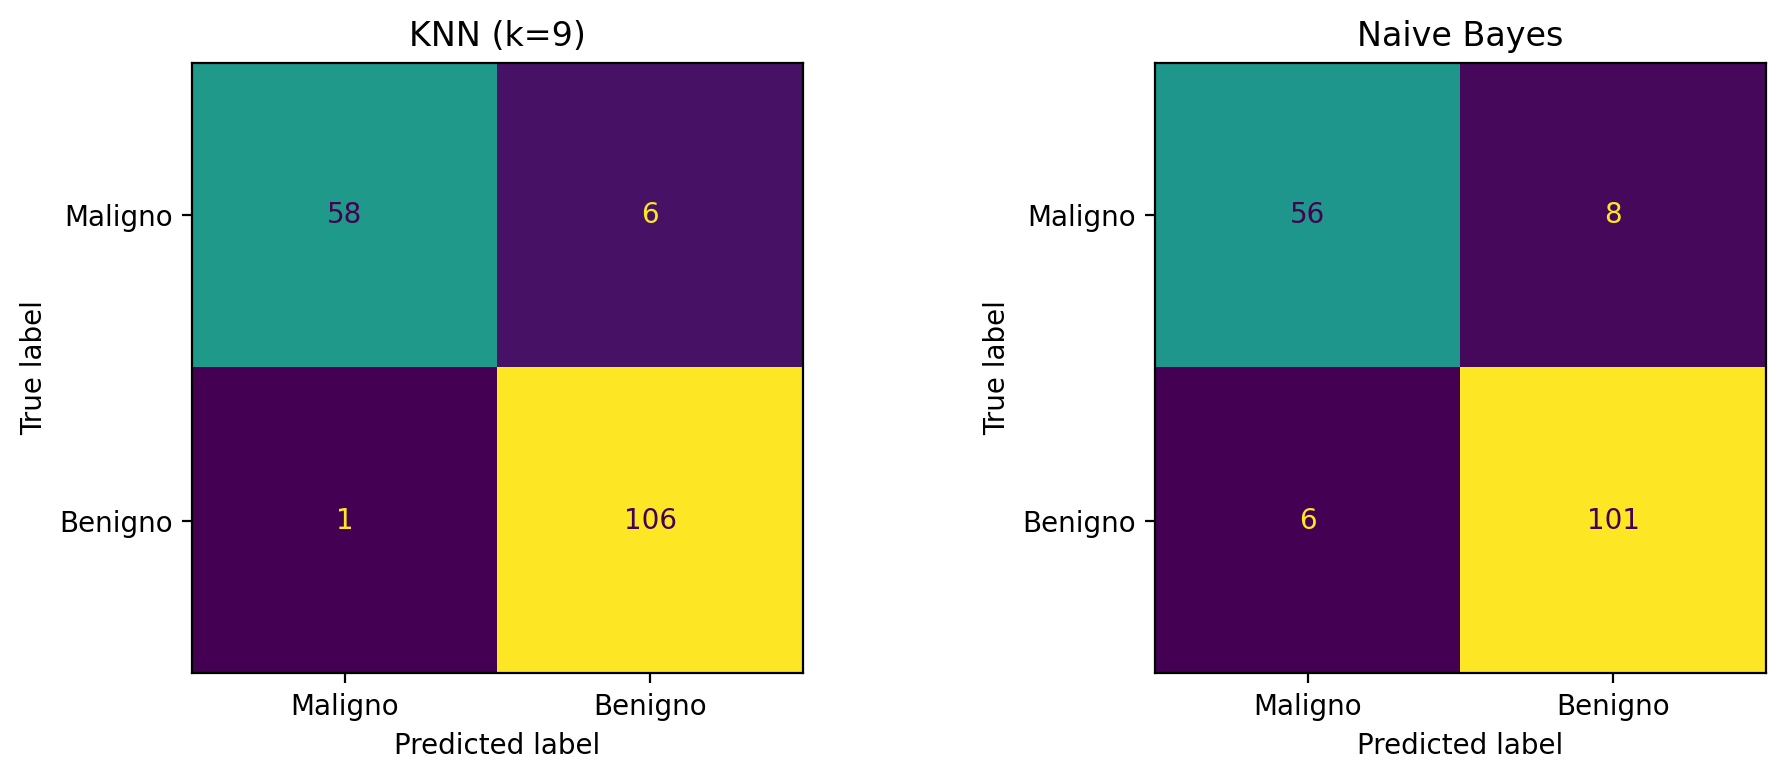

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=200)

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_knn, display_labels=["Maligno", "Benigno"], ax=axes[0], colorbar=False
)
axes[0].set_title(f"KNN (k={k_optimo})")

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_nb, display_labels=["Maligno", "Benigno"], ax=axes[1], colorbar=False
)
axes[1].set_title("Naive Bayes")

plt.tight_layout()
plt.show()

## Análisis comparativo

Sobre el conjunto de prueba (171 muestras), los resultados obtenidos fueron:

| Modelo | Exactitud | Precisión | Recall (benigno) | F1 | AUC |
|---|---|---|---|---|---|
| KNN (k=9) | 0.9591 | 0.9464 | 0.9907 | 0.9680 | **0.9856** |
| Naive Bayes | 0.9181 | 0.9266 | 0.9439 | 0.9352 | 0.9812 |

**Lectura de la curva ROC:** ambas curvas se ubican muy por encima de la diagonal de referencia y muy cerca de la esquina superior izquierda, lo que confirma que los dos modelos separan bien las clases maligno/benigno en este dataset. La curva de **KNN domina ligeramente** a la de Naive Bayes en casi todo el rango de FPR, reflejado en un AUC más alto (0.9856 frente a 0.9812). La diferencia es pequeña (~0.004), por lo que ambos clasificadores son, en la práctica, discriminadores igualmente sólidos independientemente del umbral elegido.

**Lectura de las matrices de confusión (umbral = 0.5):**

| | KNN — pred. maligno | KNN — pred. benigno | | NB — pred. maligno | NB — pred. benigno |
|---|---|---|---|---|---|
| **real maligno** | 58 | 6 | | 56 | 8 |
| **real benigno** | 1 | 106 | | 6 | 101 |

De los 64 tumores realmente malignos en el conjunto de prueba, **KNN clasifica erróneamente 6 como benignos (recall maligno = 90.6 %)**, mientras que **Naive Bayes clasifica mal 8 (recall maligno = 87.5 %)**. Ese tipo de error (falso negativo clínico) es el más costoso en un contexto de diagnóstico, y en ambos casos ocurre con cierta frecuencia — ninguno de los dos modelos es perfecto — pero KNN comete menos.

**Por qué KNN rinde mejor aquí:** Naive Bayes asume que las 30 características son condicionalmente independientes dada la clase, supuesto que no se cumple en este dataset (muchas variables están geométricamente correlacionadas entre sí, por ejemplo `mean radius`, `mean perimeter` y `mean area`). Esa violación del supuesto penaliza su desempeño frente a KNN, que no asume ninguna distribución y en cambio explota directamente la estructura de vecindad en el espacio de características ya escalado.

**Validación de las implementaciones manuales:** la diferencia máxima entre las probabilidades de las versiones manuales (`knn_predict_proba_batch`, `GaussianNaiveBayes`) y las de scikit-learn (`KNeighborsClassifier`, `GaussianNB`) fue de **0.000000** en ambos casos, confirmando que las implementaciones manuales son matemáticamente equivalentes a las de referencia.

# Conclusiones

Implementar KNN y Naive Bayes Gaussiano "desde cero" y validarlos contra `KNeighborsClassifier` y `GaussianNB` de scikit-learn (diferencia máxima de 0.000000 en ambos casos) permitió confirmar que ambos algoritmos quedaron correctamente entendidos y codificados, más allá de usarlos como caja negra.

Sobre el dataset Breast Cancer Wisconsin, **ambos modelos lograron una separación muy fuerte entre tumores malignos y benignos** (AUC de 0.9856 para KNN y 0.9812 para Naive Bayes), lo que confirma que la curva ROC es una herramienta adecuada para comparar clasificadores que producen probabilidades por mecanismos completamente distintos: KNN vía voto de vecindad y Naive Bayes vía densidad gaussiana y el teorema de Bayes.

**KNN fue consistentemente superior** en exactitud, precisión, recall y F1, y también cometió menos falsos negativos clínicos (6 tumores malignos clasificados como benignos, frente a 8 de Naive Bayes). Esto es atribuible a que el supuesto de independencia condicional entre características de Naive Bayes no se sostiene en este dataset, donde varias variables (radio, perímetro, área) están altamente correlacionadas entre sí, mientras que KNN no depende de ningún supuesto distribucional y aprovecha directamente la cercanía entre muestras en el espacio de características ya escalado.

**Limitaciones observadas:**
- KNN requiere escalar las características (aquí con `StandardScaler`) para que la distancia euclidiana no esté dominada por las variables de mayor magnitud, y su costo computacional en predicción crece con el tamaño del conjunto de entrenamiento (debe compararse contra todos los puntos).
- La elección de `k` afecta directamente el desempeño; se resolvió con validación cruzada (5-fold) en vez de fijarlo arbitrariamente, obteniendo `k = 9` como óptimo.
- Naive Bayes es más rápido de entrenar y de predecir (no memoriza los datos), pero su supuesto de independencia entre características limita su desempeño cuando estas están correlacionadas, como ocurre en este dataset.

En conjunto, el ejercicio muestra que la curva ROC y el AUC son una métrica de comparación más robusta que la exactitud simple, porque evalúan el poder discriminativo del modelo a través de todos los umbrales posibles y no dependen de una elección arbitraria (0.5), lo cual es especialmente relevante en un problema de diagnóstico donde el costo de un falso negativo y un falso positivo no es el mismo.

## Referencias

Wolberg, W. H., Street, W. N., & Mangasarian, O. L. (1995). *Breast Cancer Wisconsin (Diagnostic)* [Dataset]. UCI Machine Learning Repository. [https://doi.org/10.24432/C5DW2B](https://doi.org/10.24432/C5DW2B)

Scikit-learn developers. (s.f.). *sklearn.neighbors.KNeighborsClassifier*. Scikit-learn 1.7 documentation. [https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)

Scikit-learn developers. (s.f.). *sklearn.naive_bayes.GaussianNB*. Scikit-learn 1.7 documentation. [https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html)

Scikit-learn developers. (s.f.). *sklearn.metrics.roc_curve*. Scikit-learn 1.7 documentation. [https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html)

Fawcett, T. (2006). An introduction to ROC analysis. *Pattern Recognition Letters*, 27(8), 861-874. [https://doi.org/10.1016/j.patrec.2005.10.010](https://doi.org/10.1016/j.patrec.2005.10.010)

Hernández Parada, M. S. (2026). *Maestría en Inteligencia Artificial — Prácticas* [Repositorio de GitHub]. GitHub. [https://github.com/RKCbas/Maestria-en-Inteligencia-Artificial---Practicas/blob/main/Cuatrimestre%203/6%20-%20Aprendizaje%20inteligente/Practica%202.2/An%C3%A1lisis%2C%20implementaci%C3%B3n%20y%20prueba%20de%20m%C3%A1quinas%20de%20aprendizaje%20supervisado%20(Parte%20I).ipynb](https://github.com/RKCbas/Maestria-en-Inteligencia-Artificial---Practicas/blob/main/Cuatrimestre%203/6%20-%20Aprendizaje%20inteligente/Practica%202.2/An%C3%A1lisis%2C%20implementaci%C3%B3n%20y%20prueba%20de%20m%C3%A1quinas%20de%20aprendizaje%20supervisado%20(Parte%20I).ipynb)